# Florida school assessment results — merge & investigate

**Source.** 435 school-level workbooks from the FLDOE K-12 assessment results
pages, spring administrations **2003–2026** (no 2020 — no spring testing),
fetched with `python -m src.cli florida data assessments fetch` into
`data/florida/assessments/raw/<year>/`. File count per year varies with the
test regime: 2015–2026 has 21 files (ELA grades 3–10, Mathematics grades 3–8,
Statewide Science grades 5 & 8, and the five End-of-Course exams — Algebra 1,
Geometry, Biology 1, Civics, U.S. History); 2011–2014 (FCAT 2.0) has 16–21
(EOCs were phased in year by year); 2003–2010 (plain FCAT) has 16 — Reading,
Math, Science only, no EOCs at all. See
[`docs/data/florida/README.md`](../../../docs/data/florida/README.md) for the
download provenance and per-year `SOURCE_MANIFEST.tsv`.

**Why these files.** They are the achievement outcome for the downstream
barrier-construction event study: an annual, school-level panel of test results
running back to the mid-1990s (2003 in the digitized/collected raw stage so
far). The alternatives were rejected — SEDA v6 pools 2009–2019 with no annual
dimension, and the federal EDFacts panel is kept only as a robustness
cross-check.

**What this notebook is.** A descriptive pass over the merged assessment panel —
tables and plots only. It parses every workbook into one tidy
`school × year × subject × grade` frame *in memory* and then characterises it:
layout and merge validation, achievement-level consistency, suppression, panel
shape, the test-regime scale breaks (now four of them: FCAT → FCAT 2.0 → FSA →
FAST/B.E.S.T.), and the within-`year × subject × grade` z-score of the school
mean. **It writes no files.** Turning the parser into a persisted table is the
`florida data assessments preprocess` step. Why standardizing within a cell is
the right general fix for a scale-breaking regime change (not just *how* the
Florida-specific `z_mss`/`z_mss_w` formula works) is cross-region — see
[`shared_methodology.ipynb` §2](../shared_methodology.ipynb); Sweden's own
`meritvärde_z` uses the same idea at a coarser grouping in
[`sweden/assessments.ipynb`](../sweden/assessments.ipynb).

**Out of scope — the `schools` module.** This notebook never leaves the
assessment files. No geocoding, no `NCESSCH` / NCES EDGE coordinates, no FLDOE
MSID master-file join, no coverage judgement against the Florida school
*universe*, no "regular school" filter. The only key here is the FLDOE
**District + School number** (`msid`, 6 chars).

Final-panel-level stats — the outcome distribution, covariate/treatment structure after joining to schools and barriers — now live in [`output/notebooks/descriptive_statistics.ipynb`](../../../output/notebooks/florida/descriptive_statistics.ipynb). The subject/grade-level panel-shape analysis below stays here since it's what motivates the z-score construction in §4.


### What an FLDOE school-results file contains

Each workbook is one **spring administration × subject × grade** (EOC files pool
all grades into one sheet). A data row is a school; the columns this notebook
keeps are:

| column | meaning |
|---|---|
| `mean_scale_score` | the school's mean student **scale score** — the headline achievement metric. Its numeric range is fixed by the test: e.g. ≈ 240–412 across FSA ELA/Math grades, ≈ 200 on Statewide Science, ≈ 425–575 on the FSA EOCs — and a *different* range again on FAST / B.E.S.T. from 2023 on. |
| `pct_level3_plus` | percent of the school's students at **Achievement Level 3 or above** — Florida's "satisfactory / on grade level" bar. Levels run 1 (lowest) to 5. |
| `pct_l1 … pct_l5` | percent of students in each of the five levels (sums to ≈ 100). |
| `n_students` | number of students tested. Drives the small-cell **suppression** rule (`n < 10`, sometimes `< 20`), which blanks every score column for that row while leaving `n_students` visible. |

The event-study outcome will be `mean_scale_score`, made comparable across the
regime breaks by standardising it within each `year × subject × grade`
(section 4). `pct_level3_plus` is a coarser fallback: it is always in
"percent past a fixed bar" units, but the bar itself was re-set at each regime
change.

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREY, RED, np, pd, plt
RAW = ROOT / "data/florida/assessments/raw"
print("raw:", RAW, "\nyears:", sorted(p.name for p in RAW.glob("[0-9]" * 4)))

raw: /Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/florida/assessments/raw 
years: ['2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2021', '2022', '2023', '2024', '2025', '2026']


## 1. Parse & merge

**At least five distinct on-disk layouts** across the 435 files, and the parser
has to absorb all of them without special-casing per file:

* **wide-standard** — ELA / Math grade files, every EOC file, and Statewide
  Science from 2024 on. The header row holds `District Number, District Name,
  School Number, School Name, [Grade,] Number of Students, Mean Scale Score,
  Percentage in Level 3 or Above, 1..5`.
* **science-legacy** — Statewide Science 2015–2023. `Grade` comes *first*, the
  `1..5` columns come *before* the "% Level 3 and above" column, there are
  trailing "Mean Points Earned by Content Area" columns, and a
  "Number of Points Possible" row sits directly under the header.
* **bare-label FCAT (2004–07, grades 4–10)** — the school-name column is
  headed just `"School"`, not `"School Name"`.
* **positional-legacy FCAT (2003, grades 4–10)** — the District/School
  *number* columns carry no header text at all, only bare `"District"` /
  `"School"` (name) labels whose column position shifts inconsistently across
  files (merged header cells). Recovered from the data's fixed
  `[district_number, district_name, school_number, school_name]` column order
  instead of the label.
* **Excel-HTML export (2004–05 Science)** — a SAS-generated HTML file saved
  with an `.xls` extension, not an OLE2 binary. `parse_workbook` sniffs the
  real format and reads it with `pandas.read_html` instead.

The parser (1) finds the header row by looking for `District Number` +
`School Number` (or the bare `District`/`School` fallback), (2) maps each
header cell to a canonical name and drops the rest (content-area sub-scores,
blank spacer columns), and (3) keeps only rows whose District and School
numbers parse as integers (or are the STATE TOTALS row, recovered by text even
when its own numeric ID cells are blank) — which quietly discards the "points
possible" row and the trailing footnote lines. Every file's one surviving
`STATE TOTALS` row (`msid == "000000"`) is kept and flagged rather than
dropped: it is the statewide reference line the plots lean on.

2003–2011 also has two data-quality quirks worth knowing about (both handled
in `parse_sheet`, not visible here): 2011 ELA/Math carries a *second*,
higher-magnitude "Developmental Scale Score" column alongside the comparable
one (the parser picks the right one), and `FL2011_MATH_G07_school.xls`
appends a stale, superseded partial re-pass over a tail of districts that gets
deduplicated (`keep="last"`). See
[`docs/data/florida/README.md`](../../../docs/data/florida/README.md) for the
full list of quirks and how each was found and fixed.

This parser is not defined here — it lives in
[`src/regions/florida/sources/assessments/preprocess.py`](../../regions/florida/sources/assessments/preprocess.py)
and is what `python -m src.cli florida data assessments preprocess` runs. This
notebook imports it, builds the same in-memory frame, and investigates it; the
CLI step additionally computes the z-score and writes
`data/florida/assessments/processed/assessments.parquet`. `parse_workbook`
returns `year, subject, grade, district_number, district_name, school_number,
school_name, msid, is_state_total, suppressed` plus the eight score columns.

In [2]:
from src.regions.florida.sources.assessments.preprocess import (
    SCORE_COLS, SUBJECT_LABEL, iter_raw_files, parse_workbook, regime,
)

In [3]:
frames = [parse_workbook(p, y, s, g) for p, y, s, g in iter_raw_files()]
raw_long = pd.concat(frames, ignore_index=True)

n_files = raw_long["source_file"].nunique()
print(f"parsed {n_files} files -> {len(raw_long):,} rows "
      f"({int(raw_long.is_state_total.sum())} state-total rows)")
assert n_files == 435 and raw_long.is_state_total.sum() == 435
raw_long.head()

parsed 435 files -> 661,116 rows (435 state-total rows)


,year,subject,grade,district_number,district_name,school_number,school_name,msid,is_state_total,suppressed,n_students,mean_scale_score,pct_level3_plus,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5,source_file
0,2003,ELA,03,00,STATEWIDE AVERAGE,0000,GRADE 03,000000,True,False,188107,298,<NA>,23.0,15.0,33.0,25.0,5.0,FL2003_ELA_G03_school.xls
1,2003,ELA,03,01,ALACHUA,0021,DUVAL ELEM SCH,010021,False,False,43,299,<NA>,14.0,19.0,44.0,23.0,0.0,FL2003_ELA_G03_school.xls
2,2003,ELA,03,01,ALACHUA,0031,J.J. FINLEY ELEM,010031,False,False,72,304,<NA>,26.0,18.0,21.0,25.0,10.0,FL2003_ELA_G03_school.xls
3,2003,ELA,03,01,ALACHUA,0041,STEPHEN FOSTER ELEM,010041,False,False,50,291,<NA>,28.0,22.0,28.0,20.0,2.0,FL2003_ELA_G03_school.xls
4,2003,ELA,03,01,ALACHUA,0052,A. QUINN JONES,010052,False,True,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,FL2003_ELA_G03_school.xls


`raw_long` is the union of all 435 files — one row per school per file, plus one
`STATE TOTALS` row per file (435 in total). Nothing has been dropped for
*content* yet: `suppressed` rows are still present (with `NaN` scores), and both
layouts have been flattened to the same columns. The `_to_id` coercion is what
fixed an earlier bug — one 2018 file stored the ID columns as numbers, so
`"01"` arrived as `1` and a naive string filter silently deleted every
low-numbered school.

### Derived columns

* `subject_label` — a readable subject name for plot legends.
* `regime` — the scoring system in force, the single most important grouping in
  this notebook. Four eras run in sequence for ELA / Math: **FCAT** (2003–10)
  → **FCAT 2.0** (2011–14) → **FSA** (2015–22) → **FAST** (2023–). Algebra 1 /
  Geometry didn't exist before 2011 (no EOCs under plain FCAT), then run
  **NGSSS EOC** (2011–14) → **FSA** (2015–22) → **B.E.S.T.** (2023–). Biology 1,
  Civics and U.S. History (**NGSSS EOC**) run unbroken from their introduction
  (2011/2012/2013) through the whole period. Science is **SSS Science**
  (2003–10, pre-NGSSS) → **NGSSS Science** (2011–). Scale scores are
  comparable **only within a `regime × subject × grade`**.
* `retrofitted_2015` — 2015 FSA results were released before achievement levels
  existed (the cut scores were adopted in January 2016 and applied backward),
  hence the "reported as percentile scores" note in those files. Flagged so
  section 3 can test whether the 2015 scale nonetheless lines up with 2016+.
* `fcat_equivalent_2011` — 2011 ELA/Math school reports carry only an "FCAT
  Equivalent" score: a one-year crosswalk onto the legacy (pre-2.0) FCAT scale
  for transition continuity, not FCAT 2.0's own native per-grade scale that
  2012–14 report directly. It is its own flag rather than its own `regime`
  value on purpose — the check below finds 2011 is a smooth *continuation* of
  the 2003–10 FCAT trend, but does **not** connect smoothly to 2012–14 even
  though both share the `"FCAT 2.0"` regime label. So `regime` alone
  understates where the real scale break sits for this one year; this flag is
  what tells you not to trust raw-scale continuity across 2011→2012 despite
  the shared label.
* `cell` — the `year|subject|grade` key that every consistency check and every
  standardisation groups on.

`subject_label` and `regime` are imported from the `preprocess` module so the
notebook and the CLI step agree by construction.

In [4]:
df = raw_long.copy()
df["subject_label"] = df["subject"].map(SUBJECT_LABEL)
df["regime"] = [regime(y, s) for y, s in zip(df.year, df.subject)]
df["retrofitted_2015"] = (df.year == 2015) & df.subject.isin(["ELA", "MATH", "ALG1", "GEO"])
df["fcat_equivalent_2011"] = (df.year == 2011) & df.subject.isin(["ELA", "MATH"])
df["cell"] = df.year.astype(str) + "|" + df.subject + "|" + df.grade

state = df[df.is_state_total].copy()
school = df[~df.is_state_total].copy()
print(f"school rows: {len(school):,}   state rows: {len(state)}   "
      f"distinct schools (msid): {school.msid.nunique():,}")
school.groupby(["subject", "regime"]).size().unstack("regime", fill_value=0)

school rows: 660,681   state rows: 435   distinct schools (msid): 5,039


regime,B.E.S.T.,FAST,FCAT,FCAT 2.0,FSA,NGSSS EOC,NGSSS Science,SSS Science
subject,,,,,,,,
ALG1,7574,0,0,0,12049,4838,0,0
BIO1,0,0,0,0,0,15703,0,0
CIVICS,0,0,0,0,0,14896,0,0
ELA,0,52260,82255,46729,86502,0,0,0
GEO,6740,0,0,0,10478,3820,0,0
MATH,0,45329,70331,39926,74282,0,0,0
SCI,0,0,0,0,0,0,52234,23232
USHIST,0,0,0,0,0,11503,0,0


In [5]:
# numeric summary of the reported (non-suppressed) school rows
school.loc[~school.suppressed, SCORE_COLS].describe().round(1)

,n_students,mean_scale_score,pct_level3_plus,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5
count,593095.0,593111.0,566373.0,585523.0,585523.0,585523.0,582408.0,582408.0
mean,143.8,297.7,55.8,22.7,21.7,26.8,18.8,10.2
std,130.9,72.8,21.9,17.4,9.6,10.0,10.9,11.1
min,10.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,63.0,234.0,41.0,10.0,15.0,21.0,11.0,3.0
50%,103.0,307.0,57.0,19.0,22.0,27.0,18.0,7.0
75%,168.0,331.0,72.0,31.0,28.0,33.0,26.0,14.0
max,1715.0,559.0,100.0,100.0,88.0,99.0,94.0,99.0


This pooled summary deliberately mixes scales (FSA ELA ≈ 300, Science ≈ 200,
EOC ≈ 500, FAST ≈ 230), so the combined mean and SD carry no meaning — read it
only as a **range check**: counts non-negative, every percentage inside 0–100,
`mean_scale_score` never absurd, no all-`NaN` column. Regime-specific summaries
follow in section 3.

## 2. Validate the merge

Four checks, each targeting a specific way the parse could have gone wrong:

1. **Do `pct_l1..pct_l5` sum to ~100?** — confirms those five columns were
   mapped correctly. The science-legacy layout orders them differently, so a
   position-based reader would scramble them here.
2. **Does `pct_l3 + pct_l4 + pct_l5` equal the reported `pct_level3_plus`?** —
   confirms the "% Level 3 or above" column is really that, and not a
   "% Level 2+" or a content-area sub-score sitting in the same position.
3. **Is `(year, subject, grade, msid)` unique?** — the merge key; a school must
   appear once per cell.
4. **Are the district numbers plausible?** — the check that surfaced the
   numeric-ID bug above.

rows with no achievement-level data at all: 7,588 ({(2003, 'SCI'): 2471, (2004, 'SCI'): 2525, (2005, 'MATH'): 1, (2005, 'SCI'): 2578, (2006, 'ELA'): 3, (2006, 'SCI'): 10})


L1..L5 sum within [98,102]: 1.0000   (range 98-102)
|(L3+L4+L5) - reported %L3+|  <= 1: 1.0000   (max 1)


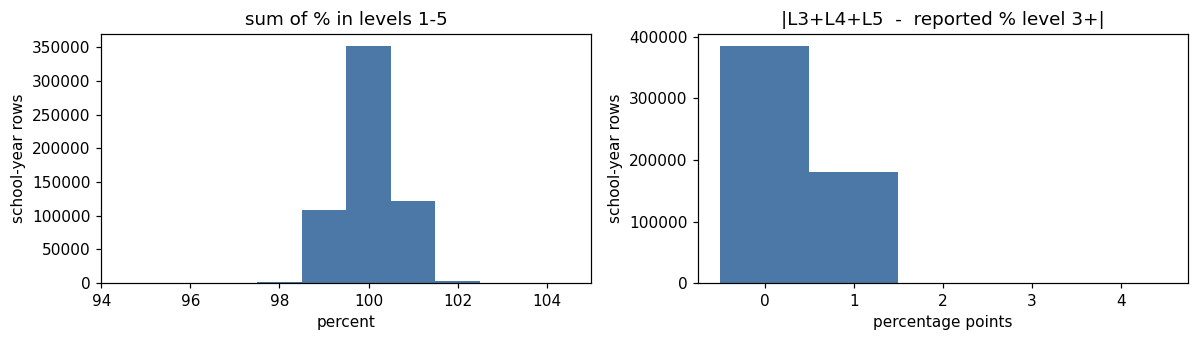

In [6]:
# achievement-level internal consistency (non-suppressed school rows)
ok = school[~school.suppressed]
level_cols = ["pct_l1", "pct_l2", "pct_l3", "pct_l4", "pct_l5"]
# 2003-05 Science predates FLDOE finalizing Science achievement levels -- those
# rows carry no level percentages at all (not suppression, not a parsing gap;
# see the note below), so exclude them from this check rather than count an
# all-NaN row (pandas .sum() silently turns into 0) as a violation.
has_levels = ok[level_cols].notna().any(axis=1)
scored = ok[has_levels]
print(f"rows with no achievement-level data at all: {(~has_levels).sum():,} "
      f"({ok[~has_levels].groupby(['year', 'subject']).size().to_dict()})")

lv_sum = scored[level_cols].sum(axis=1)
l3p_gap = (scored.pct_l3 + scored.pct_l4 + scored.pct_l5 - scored.pct_level3_plus).abs()
print("L1..L5 sum within [98,102]: %.4f   (range %.0f-%.0f)"
      % (lv_sum.between(98, 102).mean(), lv_sum.min(), lv_sum.max()))
print("|(L3+L4+L5) - reported %%L3+|  <= 1: %.4f   (max %.0f)"
      % ((l3p_gap <= 1).mean(), l3p_gap.max()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(lv_sum, bins=range(95, 106), align="left", color=BLUE)
ax[0].set_title("sum of % in levels 1-5"); ax[0].set_xlabel("percent")
ax[1].hist(l3p_gap, bins=range(0, 6), align="left", color=BLUE)
ax[1].set_title("|L3+L4+L5  -  reported % level 3+|"); ax[1].set_xlabel("percentage points")
for a in ax:
    a.set_ylabel("school-year rows")
plt.tight_layout(); plt.show()

Both checks pass for 100% of school rows that actually carry achievement-level
data — the histograms sit entirely on 100 and on 0. The `±2` / `±1` slack is
FLDOE's own rounding; the note at the top of every workbook says "percentages
may not add to 100 due to rounding". The column mapping is therefore
trustworthy across every layout.

The rows excluded above are not a bug: **2003–05 Science genuinely has no
achievement-level percentages**. FLDOE hadn't yet set Science cut scores that
early — the raw cell for `pct_l1..pct_l5` literally reads `"To Be Determined"`,
and the 2004–05 files' own SAS-export footnote says *"Science Achievement
Levels have not been determined"*. `mean_scale_score` is still reported and
usable for those three years; only the level breakdown is missing.

In [7]:
# duplicate keys & district sanity
dup = school.groupby(["year", "subject", "grade", "msid"]).size()
print("duplicate (year, subject, grade, msid) keys:", int((dup > 1).sum()))

dd = (school.groupby("district_number")
      .agg(name=("district_name", "first"), rows=("msid", "size"),
           schools=("msid", "nunique")))
print(f"\ndistinct districts: {len(dd)}   number range {dd.index.min()}-{dd.index.max()}")
print("non-county district numbers (>= 68):")
dd[dd.index >= "68"]

duplicate (year, subject, grade, msid) keys: 0

distinct districts: 79   number range 01-82
non-county district numbers (>= 68):


,name,rows,schools
district_number,,,
68,FL SCH DEAF/BLI,920,9
71,VIRTUAL PILOT,419,7
72,FAU HENDERSON,661,2
73,FSU SCH,588,2
74,FAMU SCH,429,1
75,UF PK YONGE,419,1
77,STATE COLLEGES,8,1
78,FL CONNECTIONS,112,18
79,FL VIRTUAL SCHO,76,1


No duplicate keys. Florida has 67 county districts plus a handful of
**state-operated "districts"**: the university lab schools (FAU / FSU / FAMU /
UF), the Florida School for the Deaf and the Blind (68), Florida Virtual School
(71), and college / charter authorisers numbered in the 70s–80s. These are
legitimate and carry real schools that belong in the panel; their `msid`s keep
the same 2-digit + 4-digit shape.

overall suppressed share of school rows: 0.102


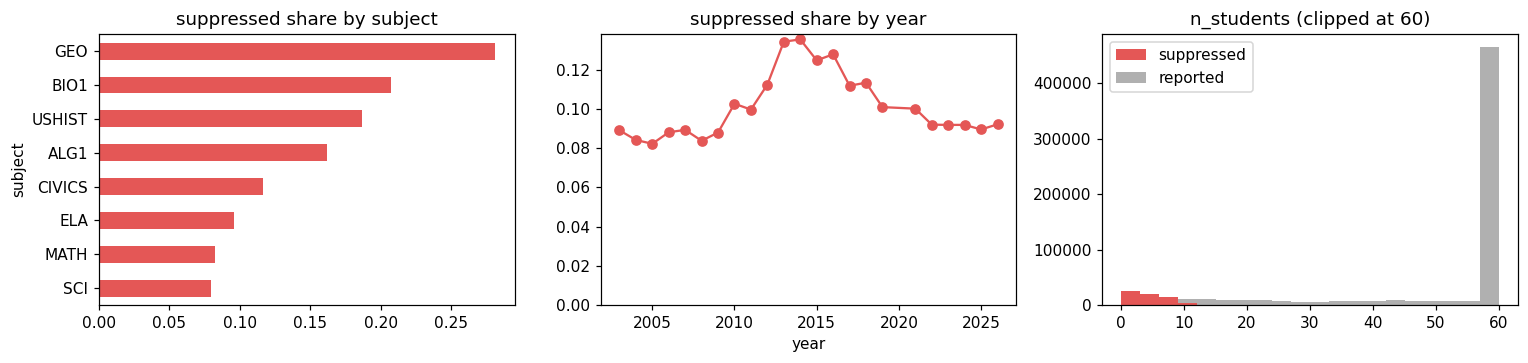

cells (year x subject x grade) with > 25% rows suppressed: 13 / 435


In [8]:
# suppression — a small-cell rule (n < 10, sometimes < 20)
print("overall suppressed share of school rows: %.3f" % school.suppressed.mean())
by_sub = school.groupby("subject").suppressed.mean().sort_values()
by_year = school.groupby("year").suppressed.mean()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
by_sub.plot.barh(ax=ax[0], color=RED); ax[0].set_title("suppressed share by subject")
by_year.plot(ax=ax[1], marker="o", color=RED); ax[1].set_title("suppressed share by year")
ax[1].set_ylim(0, None)
ns = school.dropna(subset=["n_students"])
ax[2].hist([ns.loc[ns.suppressed, "n_students"].clip(upper=60),
            ns.loc[~ns.suppressed, "n_students"].clip(upper=60)],
           bins=range(0, 62, 3), stacked=True, label=["suppressed", "reported"],
           color=[RED, GREY])
ax[2].set_title("n_students (clipped at 60)"); ax[2].legend()
plt.tight_layout(); plt.show()

cell_supp = school.groupby("cell").suppressed.mean()
print("cells (year x subject x grade) with > 25%% rows suppressed: %d / %d"
      % ((cell_supp > 0.25).sum(), len(cell_supp)))

Suppression is **not missing-at-random**: the third panel shows suppressed rows
sitting almost entirely below `n ≈ 20`, and the by-subject bars show it
concentrated in the lower-enrolment EOCs. Two consequences for the event study —
a school can move in and out of the estimation sample as a grade cohort crosses
the threshold year to year, and the schools that vanish are disproportionately
small, rural and alternative. 13 of the 435 `year × subject × grade` cells lose
more than a quarter of their rows, almost all small EOC cohorts.

### Panel shape — assessment files only

How many schools report each `subject × year` cell, and how stable that set is
over time. This is **not** a coverage statement about the Florida school
universe (which schools exist, where, when they opened / closed — that needs the
directory, i.e. the `schools` module). It only describes the internal shape of
the merged panel, so section 4's z-scores and any event study know what they
stand on.

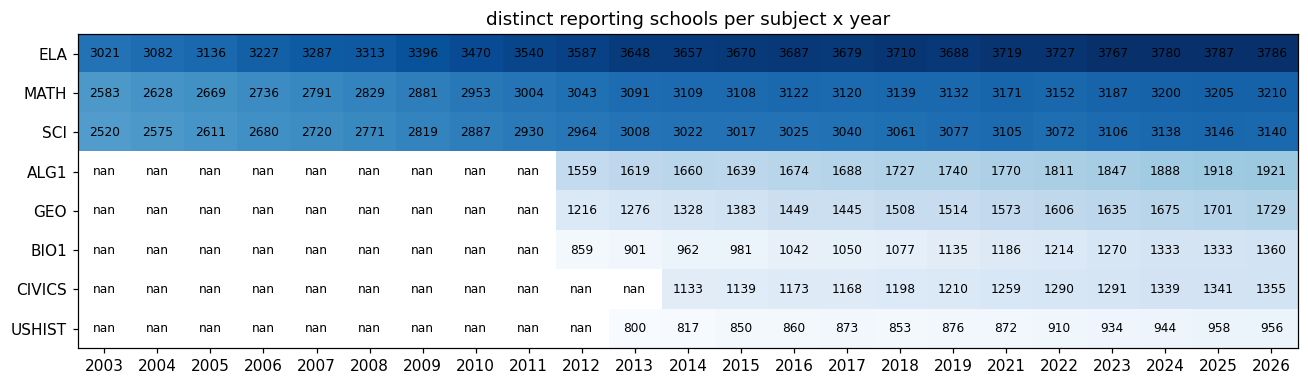

year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2021,2022,2023,2024,2025,2026
subject,,,,,,,,,,,,,,,,,,,,,,,
ELA,3021.0,3082.0,3136.0,3227.0,3287.0,3313.0,3396.0,3470.0,3540.0,3587.0,3648.0,3657.0,3670.0,3687.0,3679.0,3710.0,3688.0,3719.0,3727.0,3767.0,3780.0,3787.0,3786.0
MATH,2583.0,2628.0,2669.0,2736.0,2791.0,2829.0,2881.0,2953.0,3004.0,3043.0,3091.0,3109.0,3108.0,3122.0,3120.0,3139.0,3132.0,3171.0,3152.0,3187.0,3200.0,3205.0,3210.0
SCI,2520.0,2575.0,2611.0,2680.0,2720.0,2771.0,2819.0,2887.0,2930.0,2964.0,3008.0,3022.0,3017.0,3025.0,3040.0,3061.0,3077.0,3105.0,3072.0,3106.0,3138.0,3146.0,3140.0
ALG1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1559.0,1619.0,1660.0,1639.0,1674.0,1688.0,1727.0,1740.0,1770.0,1811.0,1847.0,1888.0,1918.0,1921.0
GEO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1216.0,1276.0,1328.0,1383.0,1449.0,1445.0,1508.0,1514.0,1573.0,1606.0,1635.0,1675.0,1701.0,1729.0
BIO1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,859.0,901.0,962.0,981.0,1042.0,1050.0,1077.0,1135.0,1186.0,1214.0,1270.0,1333.0,1333.0,1360.0
CIVICS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1133.0,1139.0,1173.0,1168.0,1198.0,1210.0,1259.0,1290.0,1291.0,1339.0,1341.0,1355.0
USHIST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,800.0,817.0,850.0,860.0,873.0,853.0,876.0,872.0,910.0,934.0,944.0,958.0,956.0


In [9]:
cov = (school.groupby(["subject", "year"]).msid.nunique()
       .unstack("year").reindex(SUBJECT_LABEL))
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.imshow(cov.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(cov.shape[1])); ax.set_xticklabels(cov.columns)
ax.set_yticks(range(cov.shape[0])); ax.set_yticklabels(cov.index)
for (i, j), v in np.ndenumerate(cov.values):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("distinct reporting schools per subject x year")
plt.tight_layout(); plt.show()
cov

ELA reaches ~3,000 (2003) to ~3,800 (2025–26) schools a year, Math ~2,600 to
~3,200, Science close behind both — the slow rise reflects both the school
system expanding and grade-configuration changes that start a school reporting
a grade it previously didn't. The EOCs are far fewer and all started in 2011+:
Algebra 1 ~1,200–1,900, U.S. History (a single high-school course) under
1,000. The next two cells break ELA / Math down by grade and quantify how much
the reporting set churns.

In [10]:
# ELA/Math: reporting schools per grade x year
for subj in ["ELA", "MATH"]:
    g = (school[school.subject == subj].groupby(["grade", "year"]).msid.nunique()
         .unstack("year"))
    print(f"\n{subj} — reporting schools per grade x year")
    print(g.to_string())


ELA — reporting schools per grade x year
year   2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2021  2022  2023  2024  2025  2026
grade                                                                                                                                          
03     1835  1877  1903  1937  1979  2005  2040  2101  2132  2161  2200  2205  2230  2242  2270  2277  2282  2324  2333  2356  2374  2362  2375
04     1830  1857  1899  1942  1980  2017  2048  2101  2139  2158  2192  2207  2207  2238  2241  2276  2273  2334  2321  2359  2362  2365  2359
05     1831  1883  1909  1950  1987  2012  2061  2114  2144  2176  2204  2203  2228  2239  2254  2277  2283  2344  2333  2363  2367  2372  2371
06      930   946   988  1004  1051  1043  1083  1138  1152  1187  1220  1255  1249  1264  1271  1315  1309  1339  1334  1377  1391  1402  1419
07      838   870   889   925   954   974   998  1052  1083  1091  1140  1177  1157  1179  119

In [11]:
# schools present in every year, and year-to-year entry / exit (ELA)
def present_all(sub):
    yrs = sorted(sub.year.unique())
    per = sub.groupby("msid").year.nunique()
    return int((per == len(yrs)).sum()), int(per.size), len(yrs)

for subj in ["ELA", "MATH", "SCI", "ALG1", "BIO1"]:
    sub = school[school.subject == subj]
    if subj in ("ELA", "MATH"):
        sub = sub[sub.grade == "05"]
    n_all, n_any, ny = present_all(sub)
    print(f"{subj:6s}: {n_all:4d} schools in all {ny} years, {n_any:4d} ever")

ela = school[school.subject == "ELA"]
seen = {y: set(g.msid) for y, g in ela.groupby("year")}
yrs = sorted(seen)
churn = pd.DataFrame(
    [(f"{a}->{b}", len(seen[b] - seen[a]), len(seen[a] - seen[b]))
     for a, b in zip(yrs, yrs[1:])],
    columns=["transition", "entered", "left"])
print()
print(churn.to_string(index=False))

ELA   : 1526 schools in all 23 years, 3037 ever


MATH  : 1524 schools in all 23 years, 3032 ever
SCI   : 2006 schools in all 23 years, 4148 ever
ALG1  : 1213 schools in all 14 years, 2484 ever
BIO1  :  618 schools in all 14 years, 1999 ever



transition  entered  left
2003->2004      127    66
2004->2005      122    68
2005->2006      132    41
2006->2007      121    61
2007->2008       95    69
2008->2009      152    69
2009->2010      152    78
2010->2011      122    52
2011->2012      123    76
2012->2013      115    54
2013->2014      102    93
2014->2015       93    80
2015->2016       77    60
2016->2017       73    81
2017->2018      100    69
2018->2019       64    86
2019->2021      116    85
2021->2022       66    58
2022->2023       84    44
2023->2024       63    50
2024->2025       62    55
2025->2026       64    65


About 1,500 schools report ELA in **every** year 2003–2026 (23 years, skipping
the 2020 gap), while ~3,000 appear at least once — roughly half the
ever-present schools are missing from at least one year, over a span this
long. Entries run higher in the 2000s (~100–150/year) than the 2010s–20s
(~60–120/year) — plausibly a maturing rather than still-expanding school
system — while exits (40–90/year) stay fairly flat throughout. The panel is
**unbalanced**; a staggered-adoption event study has to model entry / exit
rather than assume a fixed roster.

## 3. Test-regime scale breaks

Scale scores are comparable **only within a `regime × subject × grade`**. For
ELA / Math the sequence is FCAT (2003–10) → FCAT 2.0 (2011–14) → FSA (2015–22)
→ FAST (2023–); for Algebra 1 / Geometry, NGSSS EOC (2011–14) → FSA (2015–22)
→ B.E.S.T. (2023–). The other NGSSS EOCs (Biology 1, Civics, U.S. History) and
Statewide Science were never rescaled and should run flat from their
introduction through 2023→2024. In every plot below the **shaded bands mark
each regime boundary** (2010–11 FCAT→FCAT 2.0, 2014–15 FCAT 2.0→FSA, 2022–23
FSA→FAST/B.E.S.T.).

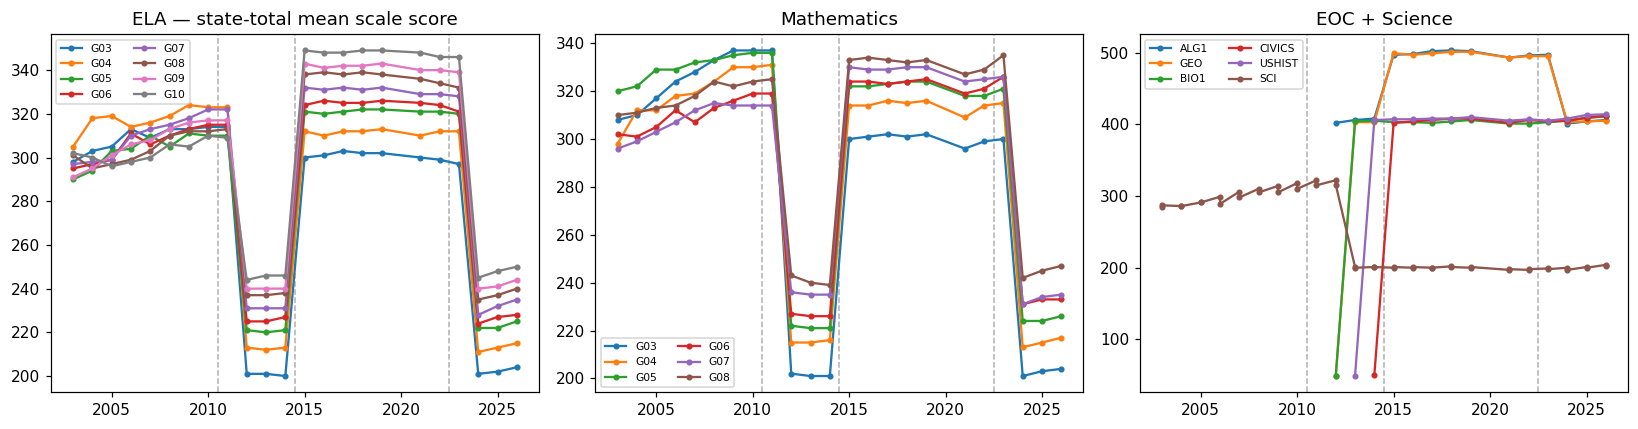

In [12]:
REGIME_BOUNDARIES = [2010.5, 2014.5, 2022.5]   # FCAT|FCAT2.0, FCAT2.0|FSA, FSA|FAST-BEST


def mark_regimes(ax):
    for x in REGIME_BOUNDARIES:
        ax.axvline(x, color="#B0B0B0", lw=1, ls="--", zorder=0)


piv = state.pivot_table(index="year", columns=["subject", "grade"], values="mean_scale_score")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for g in piv["ELA"].columns:
    axes[0].plot(piv.index, piv[("ELA", g)], marker="o", label=f"G{g}", ms=3)
axes[0].set_title("ELA — state-total mean scale score"); axes[0].legend(ncol=2, fontsize=7)
for g in piv["MATH"].columns:
    axes[1].plot(piv.index, piv[("MATH", g)], marker="o", label=f"G{g}", ms=3)
axes[1].set_title("Mathematics"); axes[1].legend(ncol=2, fontsize=7)
for subj in ["ALG1", "GEO", "BIO1", "CIVICS", "USHIST", "SCI"]:
    col = state[state.subject == subj].set_index("year").mean_scale_score
    axes[2].plot(col.index, col.values, marker="o", label=subj, ms=3)
axes[2].set_title("EOC + Science"); axes[2].legend(ncol=2, fontsize=7)
for a in axes:
    mark_regimes(a)
plt.tight_layout(); plt.show()

ELA and Math now show **three** breaks, not one: a small rise 2010→2011 (the
FCAT-equivalent crosswalk — see the dedicated check later in this section), a
sharp drop 2011→2012 (FCAT → FCAT 2.0's native scale, ~60–130 points), and the
familiar drop at 2023 (FSA→FAST, ~100 points). Algebra 1 / Geometry only exist
from 2011 on and step down once, at 2023 (FSA→B.E.S.T.). Biology 1, Civics,
U.S. History and Statewide Science carry straight through every ELA/Math
break on one line because their own scales were left alone throughout. Within
a regime the state means are near-flat, drifting a point or two a year (2021
dips slightly — the post-COVID year).

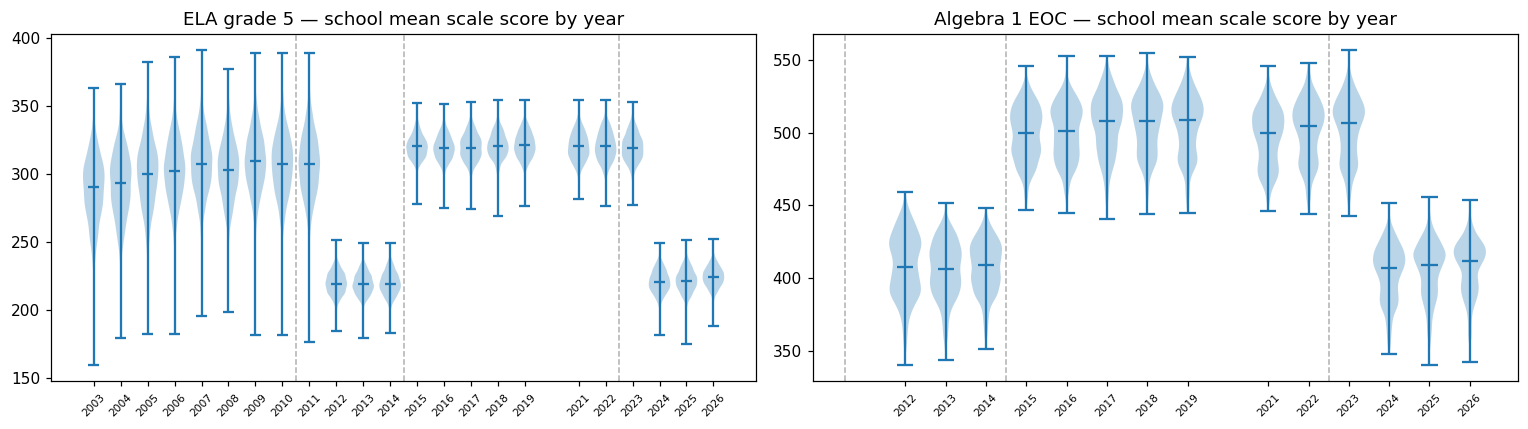

In [13]:
# school-level spread, not just the mean: distribution of school means by year
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (subj, grd, lab) in zip(
        axes, [("ELA", "05", "ELA grade 5"), ("ALG1", "EOC", "Algebra 1 EOC")]):
    sub = school[(school.subject == subj) & (school.grade == grd) & ~school.suppressed]
    yrs = sorted(sub.year.unique())
    ax.violinplot([sub.loc[sub.year == y, "mean_scale_score"].values for y in yrs],
                  positions=yrs, widths=0.8, showmedians=True)
    mark_regimes(ax)
    ax.set_title(f"{lab} — school mean scale score by year"); ax.set_xticks(yrs)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.tight_layout(); plt.show()

The violins show that at a regime change the **whole school distribution
translates**, while its width barely moves. That is exactly the situation a
within-cell z-score is built for: standardising removes a location-plus-scale
shift and leaves each school's position relative to its peers intact.

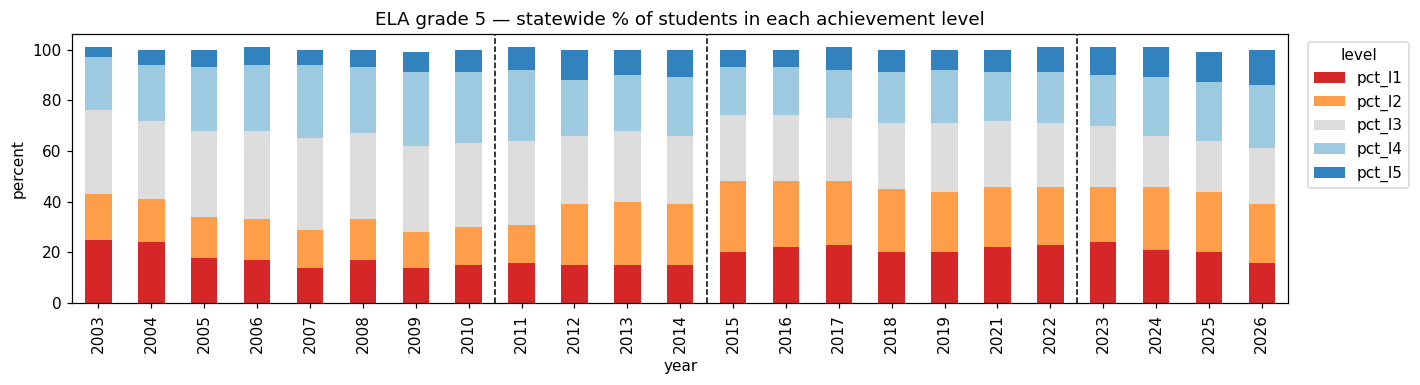

,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5
year,,,,,
2003,25.0,18.0,33.0,21.0,4.0
2004,24.0,17.0,31.0,22.0,6.0
2005,18.0,16.0,34.0,25.0,7.0
2006,17.0,16.0,35.0,26.0,7.0
2007,14.0,15.0,36.0,29.0,6.0
2008,17.0,16.0,34.0,26.0,7.0
2009,14.0,14.0,34.0,29.0,8.0
2010,15.0,15.0,33.0,28.0,9.0
2011,16.0,15.0,33.0,28.0,9.0


In [14]:
# achievement-level composition over time (state totals) — ELA grade 5
comp = (state[(state.subject == "ELA") & (state.grade == "05")]
        .set_index("year")[["pct_l1", "pct_l2", "pct_l3", "pct_l4", "pct_l5"]])
ax = comp.plot(kind="bar", stacked=True, figsize=(13, 3.6),
               color=["#D62728", "#FF9E4A", "#DDDDDD", "#9ECAE1", "#3182BD"])
ax.set_title("ELA grade 5 — statewide % of students in each achievement level")
ax.set_ylabel("percent"); ax.legend(title="level", bbox_to_anchor=(1.01, 1))
for boundary_year in (2011, 2015, 2023):   # bar plots are categorical, not numeric-x
    if boundary_year in comp.index:
        pos = list(comp.index).index(boundary_year) - 0.5
        ax.axvline(pos, color="k", lw=1, ls="--")
plt.tight_layout(); plt.show()
comp

The level mix is **re-based at each regime change by design** — FLDOE sets the
new cut scores so the statewide level distribution is roughly preserved, which
is why these bars do not jump the way the scale score does at the dashed
FSA | FAST line. That makes `pct_level3_plus` the more transportable of the two
raw metrics — but its cut score is still a *different test's* cut score before
and after 2023, so it is not clean either.

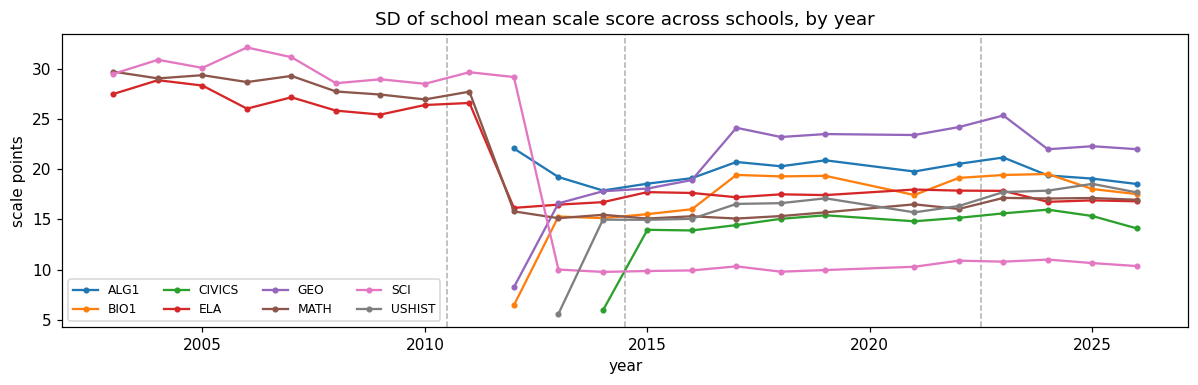

In [15]:
# dispersion across schools by year — the level shifts, the spread is stable
disp = (school[~school.suppressed].groupby(["subject", "year"]).mean_scale_score.std()
        .unstack("subject"))
ax = disp.plot(marker="o", figsize=(11, 3.6), ms=3)
ax.set_title("SD of school mean scale score across schools, by year")
ax.set_ylabel("scale points"); mark_regimes(ax)
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

Within each subject the cross-school SD stays in a fairly narrow band across
all 23 years, including straight through every regime boundary (each new
test's SD lands close to its predecessor's, by construction of how FLDOE sets
cut scores). Because the spread is stable, the within-cell z-score is
comparable **over time**, not just within one year: `z = +1` means "one
school-SD above the state" in 2005 and in 2025 alike.

### Is the 2015 *retrofitted* FSA on the 2016+ scale?

`docs/data/florida/README.md` carried a caveat that 2015 has "no scale-score
scale of its own" and should be treated as its own break. Test it directly:
compare the 2015 and 2016 school-level distributions grade by grade, and plot
the schools present in both years against the 45° line.

subject grade  mean_2015  mean_2016  d_mean  sd_2015  sd_2016
    ELA    03      299.3      300.3     1.0      9.1      9.3
    ELA    04      310.9      309.0    -1.9      8.5      9.2
    ELA    05      319.8      319.0    -0.8      8.8      9.4
    ELA    06      323.7      324.9     1.2     11.5     10.6
    ELA    07      330.9      329.7    -1.2     11.5     11.4
    ELA    08      336.6      337.0     0.4     11.8     12.4
    ELA    09      340.4      338.8    -1.6     13.8     13.6
    ELA    10      346.0      346.4     0.4     12.9     12.1
   MATH    03      299.5      300.5     1.0      8.9      9.2
   MATH    04      312.7      312.6    -0.1      9.7     10.5
   MATH    05      320.3      320.8     0.5     10.3     10.9
   MATH    06      323.3      323.0    -0.3     12.7     13.0
   MATH    07      328.3      327.2    -1.1     11.7     12.6
   MATH    08      331.7      332.2     0.5     12.3     13.7

max |d_mean| across grades: 1.9 scale points


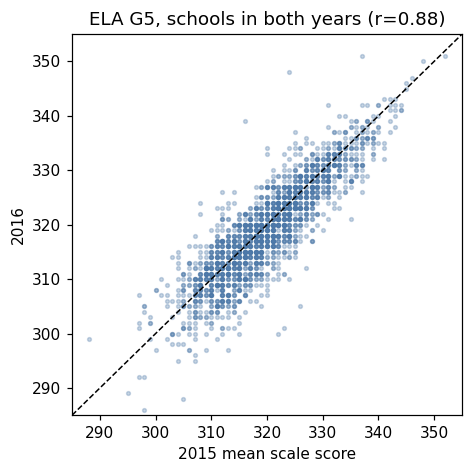

In [16]:
rows = []
for subj in ["ELA", "MATH"]:
    for g in sorted(school[school.subject == subj].grade.unique()):
        a = school.query("year==2015 and subject==@subj and grade==@g and not suppressed")
        b = school.query("year==2016 and subject==@subj and grade==@g and not suppressed")
        rows.append((subj, g, round(a.mean_scale_score.mean(), 1),
                     round(b.mean_scale_score.mean(), 1),
                     round(b.mean_scale_score.mean() - a.mean_scale_score.mean(), 1),
                     round(a.mean_scale_score.std(), 1), round(b.mean_scale_score.std(), 1)))
cmp15 = pd.DataFrame(rows, columns=["subject", "grade", "mean_2015", "mean_2016",
                                    "d_mean", "sd_2015", "sd_2016"])
print(cmp15.to_string(index=False))
print("\nmax |d_mean| across grades: %.1f scale points" % cmp15.d_mean.abs().max())

m = (school.query("subject=='ELA' and grade=='05' and not suppressed")
     .pivot_table(index="msid", columns="year", values="mean_scale_score"))
fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.scatter(m[2015], m[2016], s=6, alpha=.3, color=BLUE)
lo, hi = 285, 355
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("2015 mean scale score"); ax.set_ylabel("2016")
ax.set_title(f"ELA G5, schools in both years (r={m[[2015, 2016]].corr().iloc[0, 1]:.2f})")
plt.tight_layout(); plt.show()

The 2015→2016 shift is a point or two at every grade — the same size as the
2016→2017 wobble — the SDs match, and matched schools sit on the 45° line. So
2015 **pools into the FSA scale** and the README caveat is too strong; the
`retrofitted_2015` flag stays in the frame only for optional robustness checks.
The section-4 z-score is robust to this either way.

### Does the 2011 "FCAT Equivalent" score connect to 2010, or to 2012?

`fcat_equivalent_2011` flags a very different situation from 2015's. FLDOE's
own header text for the 2011 column says **"FCAT Equivalent Scale Score
(100-500)"** — a crosswalk designed to extend the *old* FCAT trend line one
more year, not FCAT 2.0's own native per-grade scale that 2012–14 report
directly (`"Mean Developmental Scale Score"`, no "equivalent" framing). Both
2011 and 2012 share the same `regime` label, `"FCAT 2.0"` — so if `regime`
were the only guide, they would look interchangeable. Test both boundaries the
same way as the 2015 check: 2010↔2011 (does the "equivalent" score behave like
ordinary FCAT drift?) and 2011↔2012 (does it also connect smoothly into FCAT
2.0's native scale, or does labeling both years `"FCAT 2.0"` paper over a real
break?).

2010 -> 2011 (FCAT -> FCAT-equivalent):
subject grade  mean_2010  mean_2011  d_mean
    ELA    03      312.1      312.1     0.0
    ELA    04      319.9      320.4     0.5
    ELA    05      306.4      306.7     0.3
    ELA    06      311.3      311.4     0.1
    ELA    07      315.7      315.9     0.2
    ELA    08      306.2      306.8     0.6
    ELA    09      306.0      306.5     0.5
    ELA    10      296.3      298.3     2.1
   MATH    03      334.2      334.2    -0.0
   MATH    04      326.7      327.1     0.4
   MATH    05      332.7      332.5    -0.2
   MATH    06      314.5      314.7     0.3
   MATH    07      306.0      306.8     0.8
   MATH    08      318.3      317.5    -0.7

2011 -> 2012 (FCAT-equivalent -> FCAT 2.0 native, both labeled regime=='FCAT 2.0'):
subject grade  mean_2011  mean_2012  d_mean
    ELA    03      312.1      199.8  -112.3
    ELA    04      320.4      211.9  -108.5
    ELA    05      306.7      219.6   -87.1
    ELA    06      311.4      223.5   -

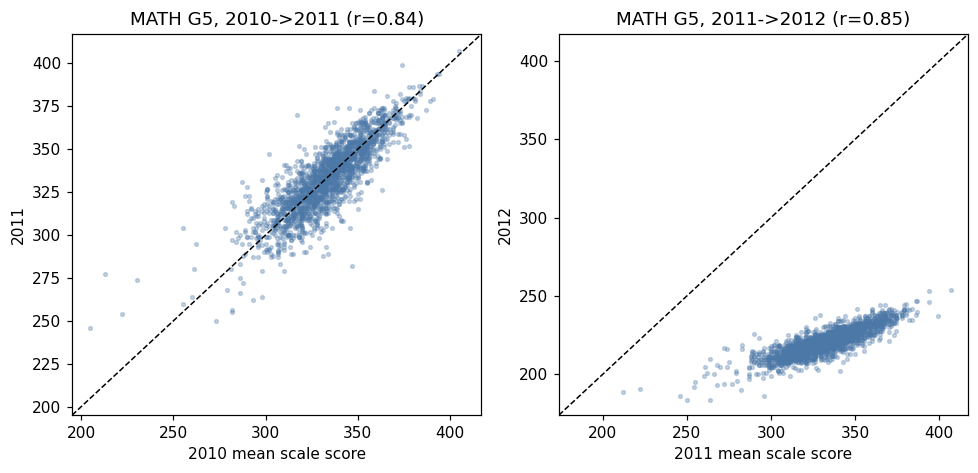

In [17]:
def transition_table(year_a, year_b):
    rows = []
    for subj in ["ELA", "MATH"]:
        for g in sorted(school[school.subject == subj].grade.unique()):
            a = school.query("year==@year_a and subject==@subj and grade==@g and not suppressed")
            b = school.query("year==@year_b and subject==@subj and grade==@g and not suppressed")
            if a.empty or b.empty:
                continue
            rows.append((subj, g, round(a.mean_scale_score.mean(), 1),
                         round(b.mean_scale_score.mean(), 1),
                         round(b.mean_scale_score.mean() - a.mean_scale_score.mean(), 1)))
    return pd.DataFrame(rows, columns=["subject", "grade", f"mean_{year_a}", f"mean_{year_b}", "d_mean"])


t_10_11 = transition_table(2010, 2011)
t_11_12 = transition_table(2011, 2012)
print("2010 -> 2011 (FCAT -> FCAT-equivalent):")
print(t_10_11.to_string(index=False))
print("\n2011 -> 2012 (FCAT-equivalent -> FCAT 2.0 native, both labeled regime=='FCAT 2.0'):")
print(t_11_12.to_string(index=False))
print("\nmax |d_mean| 2010->2011: %.1f    max |d_mean| 2011->2012: %.1f scale points"
      % (t_10_11.d_mean.abs().max(), t_11_12.d_mean.abs().max()))

fig, ax = plt.subplots(1, 2, figsize=(9, 4.4))
for a, (ya, yb) in zip(ax, [(2010, 2011), (2011, 2012)]):
    m = (school.query("subject=='MATH' and grade=='05' and not suppressed")
         .pivot_table(index="msid", columns="year", values="mean_scale_score"))
    a.scatter(m[ya], m[yb], s=6, alpha=.3, color=BLUE)
    lo, hi = m[[ya, yb]].min().min() - 10, m[[ya, yb]].max().max() + 10
    a.plot([lo, hi], [lo, hi], "k--", lw=1)
    a.set_xlim(lo, hi); a.set_ylim(lo, hi)
    a.set_xlabel(f"{ya} mean scale score"); a.set_ylabel(str(yb))
    a.set_title(f"MATH G5, {ya}->{yb} (r={m[[ya, yb]].corr().iloc[0, 1]:.2f})")
plt.tight_layout(); plt.show()

Confirmed, sharply: **2010→2011 moves 2.1 scale points at most** (every grade
within noise, same size as ordinary year-to-year drift) — the "FCAT
Equivalent" label earns its name, extending the FCAT trend cleanly one more
year. **2011→2012 moves 57 to 134 scale points**, a location shift an order of
magnitude larger, on the *same* test/grade/subject the "FCAT 2.0" regime label
treats as one continuous era. Both transitions correlate similarly at the
matched-school level (MATH G5: `r≈0.84` either way) — the *relative* ranking
of schools is about as stable across either boundary — but only 2010→2011 sits
near the 45° line; 2011→2012's cloud sits in a completely different band,
confirming the 2012 drop is a pure rescaling, not noise or a parsing error.

So: `regime` is the right grouping for the z-score (which is exactly why
section 4's standardisation absorbs this, 2011 included, without special
handling), but it is **not** a safe label for "these years are on one
comparable raw scale" — 2011 sits with 2003–10 on that dimension, not with
2012–14 despite sharing its `regime` string. `fcat_equivalent_2011` is the flag
that captures this, and any robustness check that trends the *raw*
`mean_scale_score` (rather than `z_mss`) across years must either drop 2011 or
treat it as its own one-year regime.

## 4. Within `year × subject × grade` z-score

See [`shared_methodology.ipynb` §2](../shared_methodology.ipynb) for why
standardizing within a scale-consistent cell is the right general fix for a
regime break; here's Florida's specific construction and verification.

> `z_mss = (mean_scale_score − mean over the cell's schools) / SD over the cell's schools`

`z_mss_w` does the same with the mean and SD **weighted by `n_students`**, which
approximates standardising against the student-level distribution — the
statewide *student* SD is not published, so this is the closest available proxy.
Suppressed rows carry no score and get `NaN`; state-total rows are excluded from
the moments.


per-cell z_mss — mean ~0, sd ~1:
      mean   sd
mean   0.0  1.0
min   -0.0  1.0
max    0.0  1.0


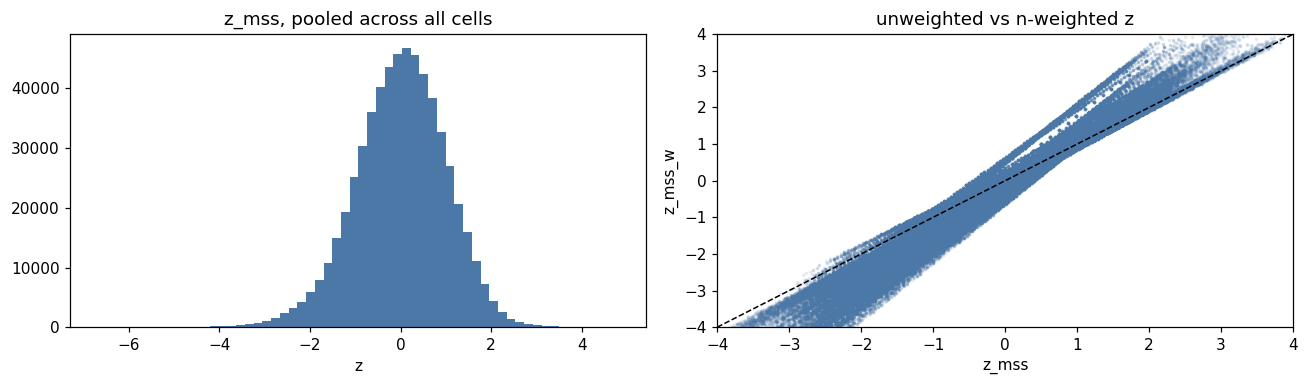

In [18]:
def _z(g: pd.DataFrame) -> pd.DataFrame:
    x = g.mean_scale_score
    z = (x - x.mean()) / x.std()
    w, ok = g.n_students, g.n_students.notna() & x.notna()
    if ok.any() and w[ok].sum() > 0:
        mu = np.average(x[ok], weights=w[ok])
        sd = np.sqrt(np.average((x[ok] - mu) ** 2, weights=w[ok]))
        zw = (x - mu) / sd if sd > 0 else pd.Series(np.nan, index=g.index)
    else:
        zw = pd.Series(np.nan, index=g.index)
    return pd.DataFrame({"z_mss": z, "z_mss_w": zw})


valid = school[~school.suppressed].copy()
school = school.join(valid.groupby("cell", group_keys=False).apply(_z))

chk = (school.dropna(subset=["z_mss"]).groupby("cell")
       .agg(mean=("z_mss", "mean"), sd=("z_mss", "std")))
print("per-cell z_mss — mean ~0, sd ~1:")
print(chk.agg(["mean", "min", "max"]).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(school.z_mss.dropna(), bins=60, color=BLUE)
ax[0].set_title("z_mss, pooled across all cells"); ax[0].set_xlabel("z")
ax[1].scatter(school.z_mss, school.z_mss_w, s=2, alpha=.1, color=BLUE)
ax[1].plot([-4, 4], [-4, 4], "k--", lw=1)
ax[1].set_xlim(-4, 4); ax[1].set_ylim(-4, 4)
ax[1].set_title("unweighted vs n-weighted z"); ax[1].set_xlabel("z_mss"); ax[1].set_ylabel("z_mss_w")
plt.tight_layout(); plt.show()

Per cell the z-score is mean 0, SD 1 by construction. Pooled across all cells it
is close to standard normal but a touch heavy-tailed and slightly left-skewed —
a handful of very-low-performing alternative schools. Unweighted and weighted z
track closely (points near the 45° line); they diverge most where one large
school pulls the weighted mean, so keep both and let the downstream spec choose.

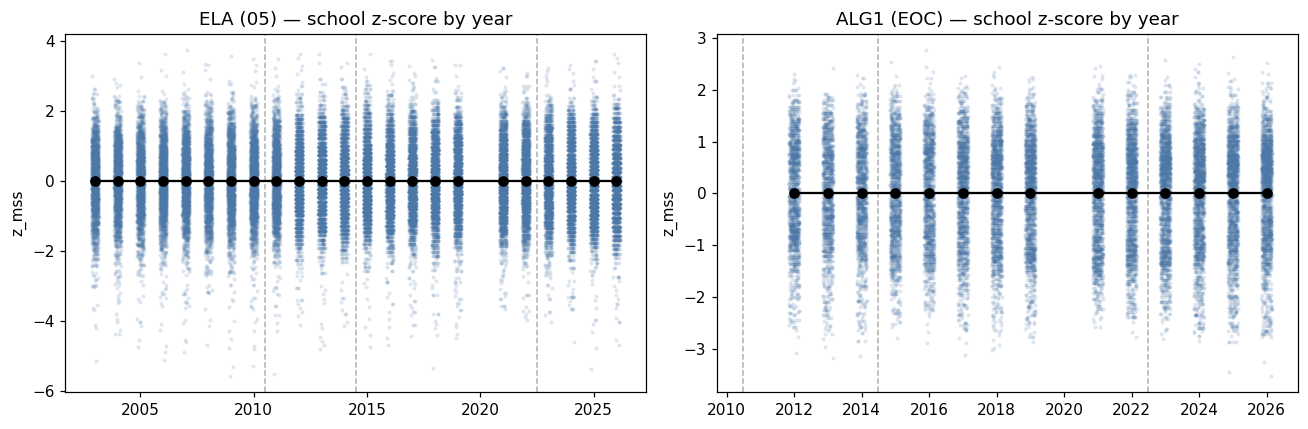

within-school year-to-year change in z_mss:
  mean -0.009   sd 0.474   IQR [-0.27, 0.25]


In [19]:
# the z-score is continuous across every regime break, not just 2023->2024
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for (subj, grd), a in zip([("ELA", "05"), ("ALG1", "EOC")], ax):
    sub = school[(school.subject == subj) & (school.grade == grd) & ~school.suppressed]
    a.scatter(sub.year + np.random.uniform(-.15, .15, len(sub)), sub.z_mss,
              s=3, alpha=.12, color=BLUE)
    a.plot(sorted(sub.year.unique()), sub.groupby("year").z_mss.mean().values,
           color="k", marker="o")
    mark_regimes(a)
    a.set_title(f"{subj} ({grd}) — school z-score by year"); a.set_ylabel("z_mss")
plt.tight_layout(); plt.show()

d = (school.dropna(subset=["z_mss"]).sort_values("year")
     .groupby(["subject", "grade", "msid"]).z_mss.diff())
print("within-school year-to-year change in z_mss:")
print("  mean %.3f   sd %.3f   IQR [%.2f, %.2f]"
      % (d.mean(), d.std(), d.quantile(.25), d.quantile(.75)))

The black line — mean school z by year — sits on ~0 throughout with **no step
at any of the three regime breaks** (2011, 2012, 2023), confirming the
standardisation absorbs every scale change, including the one *inside* the
`"FCAT 2.0"` label that `regime` alone would miss; the point cloud keeps the
same vertical spread every year. The usable signal is the within-school
year-to-year change, `Δz_mss`, with SD ≈ 0.47: about half a school-SD of
idiosyncratic movement a year, which is the noise a barrier-construction
effect would have to be detected against.

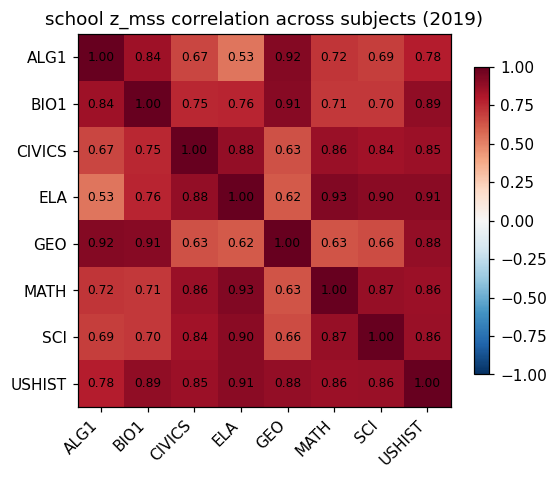

In [20]:
# how do a school's subjects move together? correlation of school z_mss, 2019
w = (school.query("year == 2019 and not suppressed")
     .assign(key=lambda t: np.where(t.grade == "EOC", t.subject, t.subject + t.grade))
     .pivot_table(index="msid", columns="subject", values="z_mss"))
corr = w.corr()
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=.8); ax.set_title("school z_mss correlation across subjects (2019)")
plt.tight_layout(); plt.show()

Within a year a school's subjects move together but far from perfectly — ELA and
Math z-scores correlate ≈ 0.8, the EOCs less. So the subjects carry partly
independent information: stacking them raises statistical power, and an effect
that turns up in one subject but not the others is a useful placebo / spec
check.

## 5. Summary

* **435 / 435 workbooks parse** into 661k `school × year × subject × grade`
  rows (≈ 5.0k distinct `msid`), one `STATE TOTALS` row per file, across
  **five distinct on-disk layouts** (wide-standard, science-legacy,
  bare-label FCAT, positional-legacy FCAT, Excel-HTML export) that all flatten
  to the same columns. Achievement levels sum to 100 (± rounding) and
  `L3+L4+L5 == reported % level 3+` everywhere **except** 2003–05 Science,
  which genuinely has no levels yet (FLDOE's own "not yet determined" note,
  not suppression or a parsing gap); no duplicate `(year, subject, grade,
  msid)` keys.
* **Suppression** blanks the score columns for ≈ 10 % of school rows — an
  `n < 10` (sometimes `< 20`) rule, so it is non-random: it removes small,
  rural and alternative schools, and moves a school in and out of the sample as
  its cohort crosses the threshold. 13 / 435 cells lose >25 % of rows.
* **Panel is unbalanced over 23 years** — ~1,500 schools report ELA every year
  2003–2026, ~3,000 ever; entries run ~100–150/year in the 2000s, down to
  ~60–120/year by the 2010s–20s, while exits stay flat around 40–90/year.
* **Regime breaks are now three, not one**: 2010→2011 is a smooth
  FCAT-equivalent crosswalk (≤2.1 points, same size as ordinary drift);
  2011→2012 is a sharp native-scale break (57–134 points) **despite both years
  sharing the `"FCAT 2.0"` regime label** — exactly why `fcat_equivalent_2011`
  exists as a separate flag, not folded into `regime`; 2023→2024 is the
  familiar FSA→FAST/B.E.S.T. break (~100 points). Biology 1 / Civics / U.S.
  History and Statewide Science are flat throughout, as expected. The
  **cross-school SD is stable through every break** even though the level
  jumps.
* **2015 retrofitted FSA is on the 2016+ scale** — matched-school 2015↔2016
  means differ by ≤ 1.9 points, the same magnitude as ordinary year-to-year
  drift.
* The **within-`year × subject × grade` z-score** is ~N(0, 1) per cell by
  construction and runs continuously across all three scale breaks —
  including the 2011→2012 break that `regime` alone doesn't flag; within-school
  year-to-year Δz has SD ≈ 0.47 — the variation an event study would use.

**No file is written here.** The harmonised table and the z-score belong in the
`florida data assessments preprocess` step; the `msid → NCESSCH` crosswalk,
coordinates and the open / close + regular-school panel filter belong to
`schools` + `master_file`.